In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

In [ ]:
# Read experimental data (starch = almidon)
almidon_data = np.loadtxt('almidon.txt')
tiempo = almidon_data[:, 0]
almidon = almidon_data[:, 1]

In [3]:
# Model
def css(t, x, params):
    # Parameters
    yxs, ms = params
    mumax, kd, k, yxni, kn = 0.23, 0.025, 1.34e-4, 20.4, 7e-4
    # Differential equations
    # Biomass
    dx1 = mumax * x[2] / (kn + x[2]) * x[0] - kd * x[0]
    # Urea [2] and intermediate nitrogen [3]
    if x[1] > 0:
        dx2 = -k
        dx3 = 0.47 * k - mumax * x[2] / (kn + x[2]) * x[0] / yxni
    else:
        dx2 = 0
        dx3 = 0 - mumax * x[2] / (kn + x[2]) * x[0] / yxni
    # Starch
    dx4 = -mumax * x[2] * x[0] / (kn + x[2]) / yxs - ms * x[0]
    return [dx1, dx2, dx3, dx4]

In [4]:
# Integration interval for all simulations
t_span = (0, 150)

# Construct residuals: difference between the model and the experimental starch data
def int_css(params):
    X0 = [4.7e-3, 3.5e-3, 0, 0.18]
    # Integrate at the same sampling times as the experimental data
    sol = solve_ivp(css, t_span, X0, args=(params,), t_eval=tiempo)
    return sol.y[3] - almidon

# least_squares optimization routine
initial_guess = [1.0, 0.5]
result = least_squares(int_css, initial_guess)

# Extract estimated parameters
params = result.x

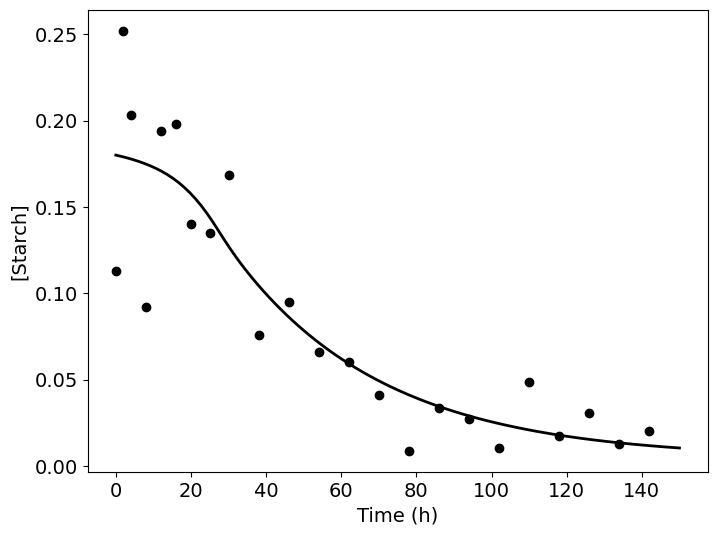

Convergence message: `gtol` termination condition is satisfied.
Estimated parameters:
  yxs: 1.99
  ms: 0.104
- Error (resnorm): 0.0243


In [5]:
# Comparison between experimental data and model predictions
X0 = [4.7e-3, 3.5e-3, 0, 0.18]
t_sim = np.linspace(0, 150, 100)
almidon_sim = solve_ivp(css, t_span, X0, args=(params,), t_eval=t_sim).y[3]

plt.figure(figsize=(8,6))
plt.plot(tiempo, almidon, 'ko')
plt.plot(t_sim, almidon_sim, 'k-', lw=2)
plt.xlabel('Time (h)', fontsize=14)
plt.ylabel('[Starch]', fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.show()

print("Convergence message:", result.message)
print('Estimated parameters:')
print('  yxs:', round(params[0], 2))
print('  ms:', round(params[1], 3))
print(f'- Error (resnorm): {round(2*result.cost, 4)}')